<a href="https://colab.research.google.com/github/anasnisar123/Finite-Element-Analysis/blob/main/Jax-FEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install --quiet --upgrade "jax[cpu]"
!pip install --quiet flax optax


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.2 MB/s eta 0:00:00


In [ ]:
import jax
import jax.numpy as jnp

print("Devices:", jax.devices())
x = jnp.linspace(0.0, 1.0, 5)
print("linspace test:", x)


Devices: [CpuDevice(id=0)]
linspace test: [0.   0.25 0.5  0.75 1.  ]


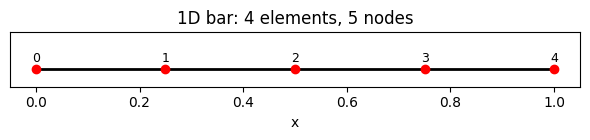

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- build 1x4 bar ---
length = 1.0
n_elem = 4
n_node = n_elem + 1

x = np.linspace(0.0, length, n_node)      # node coordinates
elements = np.array([[e, e+1] for e in range(n_elem)], dtype=int)

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 1.5))

# plot elements as line segments
for e in elements:
    i, j = e
    ax.plot([x[i], x[j]], [0, 0], 'k-', lw=2)

# plot nodes
ax.plot(x, np.zeros_like(x), 'ro', ms=6)

# label nodes
for i, xi in enumerate(x):
    ax.text(xi, 0.02, f'{i}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(-0.1, 0.2)
ax.set_xlim(-0.05, length + 0.05)
ax.set_yticks([])
ax.set_xlabel("x")
ax.set_title("1D bar: 4 elements, 5 nodes")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- problem data ---
L = 1.0
n_elem = 4
n_node = n_elem + 1
E = 100.0
A = 1.0
F = 10.0

# --- mesh ---
x = np.linspace(0.0, L, n_node)
elements = np.array([[e, e+1] for e in range(n_elem)], dtype=int)

# --- assemble stiffness ---
K = np.zeros((n_node, n_node))
Le = L / n_elem
k_e = E * A / Le
for e in elements:
    i, j = e
    Ke = k_e * np.array([[1, -1],
                         [-1, 1]])
    K[np.ix_([i, j], [i, j])] += Ke

# --- load vector ---
f = np.zeros(n_node)
f[-1] = F          # axial load at node 4

# --- apply BC: node 0 fixed ---
free = np.arange(1, n_node)
K_ff = K[np.ix_(free, free)]
f_f  = f[free]

print ("Stiffness matrix = \n", K_ff)
print ("Force matrix = \n", + f_f)

Stiffness matrix = 
 [[ 800. -400.    0.    0.]
 [-400.  800. -400.    0.]
 [   0. -400.  800. -400.]
 [   0.    0. -400.  400.]]
Force matrix = 
 [ 0.  0.  0. 10.]


nodal displacements: [0.    0.025 0.05  0.075 0.1  ]


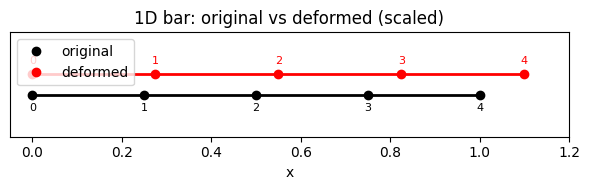

Displacement at node 4 = 0.10000000000000006


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- problem data ---
L = 1.0
n_elem = 4
n_node = n_elem + 1
E = 100.0
A = 1.0
F = 10.0

# --- mesh ---
x = np.linspace(0.0, L, n_node)
elements = np.array([[e, e+1] for e in range(n_elem)], dtype=int)

# --- assemble stiffness ---
K = np.zeros((n_node, n_node))
Le = L / n_elem
k_e = E * A / Le
for e in elements:
    i, j = e
    Ke = k_e * np.array([[1, -1],
                         [-1, 1]])
    K[np.ix_([i, j], [i, j])] += Ke

# --- load vector ---
f = np.zeros(n_node)
f[-1] = F          # axial load at node 4

# --- apply BC: node 0 fixed ---
free = np.arange(1, n_node)
K_ff = K[np.ix_(free, free)]
f_f  = f[free]

u_f = np.linalg.solve(K_ff, f_f)
u = np.zeros(n_node)
u[free] = u_f      # nodal displacements

print("nodal displacements:", u)

# --- visualization ---
scale = 1.0  # you can increase this to exaggerate deformation

x_def = x + scale * u  # new positions after deformation

fig, ax = plt.subplots(figsize=(6, 2))

# original configuration (black)
for e in elements:
    i, j = e
    ax.plot([x[i], x[j]], [0, 0], 'k-', lw=2)
ax.plot(x, np.zeros_like(x), 'ko', label="original")

# deformed configuration (red)
for e in elements:
    i, j = e
    ax.plot([x_def[i], x_def[j]], [0.05, 0.05], 'r-', lw=2)
ax.plot(x_def, 0.05*np.ones_like(x_def), 'ro', label="deformed")

# label nodes
for i, (xo, xd) in enumerate(zip(x, x_def)):
    ax.text(xo, -0.02, f'{i}', ha='center', va='top', fontsize=8, color='k')
    ax.text(xd, 0.07, f'{i}', ha='center', va='bottom', fontsize=8, color='r')

ax.set_ylim(-0.1, 0.15)
ax.set_xlim(-0.05, L + 0.2)
ax.set_yticks([])
ax.set_xlabel("x")
ax.set_title("1D bar: original vs deformed (scaled)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

print("Displacement at node 4 =", u[-1])


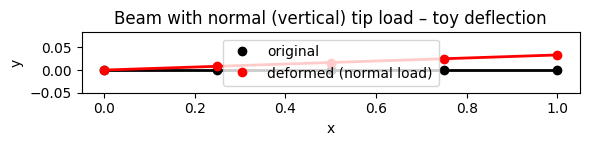

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

L = 1.0
n_node = 5          # 4 elements
x = np.linspace(0.0, L, n_node)
y = np.zeros_like(x)

coords = np.stack([x, y], axis=1)   # (N,2)
elements = np.array([[i, i+1] for i in range(n_node-1)], dtype=int)

E = 100.0          # Pa
I = 1.0            # assume unit moment of inertia for toy
P = 10.0           # vertical load (N)
L = 1.0

# Tip deflection from Euler–Bernoulli cantilever formula:
wL = P * L**3 / (3 * E * I)

# Create a simple cubic shape from 0 to wL along the beam
xi = x / L
w = wL * (2*xi**3 - 3*xi**2 + 1) * 0  # zero at left and right unless you want real shape
# For a quick visual: just linearly interpolate:
w = wL * xi   # simple linear deflection, easier

coords_def = np.stack([x, y + w], axis=1)

fig, ax = plt.subplots(figsize=(6,2))

# original
for e in elements:
    i, j = e
    ax.plot([coords[i,0], coords[j,0]],
            [coords[i,1], coords[j,1]], 'k-', lw=2)
ax.plot(coords[:,0], coords[:,1], 'ko', label="original")

# deformed
for e in elements:
    i, j = e
    ax.plot([coords_def[i,0], coords_def[j,0]],
            [coords_def[i,1], coords_def[j,1]], 'r-', lw=2)
ax.plot(coords_def[:,0], coords_def[:,1], 'ro', label="deformed (normal load)")

ax.set_aspect('equal', 'box')
ax.set_xlim(-0.05, L+0.05)
ax.set_ylim(min(w)-0.05, max(w)+0.05)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Beam with normal (vertical) tip load – toy deflection")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import jax
import jax.numpy as jnp
import optax
from flax import linen as nn

# -------------------------
# Problem setup: 1D bar
# -------------------------
L = 1.0
n_elem = 4
n_node = n_elem + 1
E = 100.0
A = 1.0

# mesh: 5 nodes, 4 elements
x = jnp.linspace(0.0, L, n_node)
elements = jnp.stack(
    [jnp.arange(0, n_node-1), jnp.arange(1, n_node)],
    axis=1
)  # shape (4,2)

print (elements)
Le = L / n_elem
k_e = E * A / Le

fixed = jnp.array([0], dtype=int)
print (fixed)

[[0 1]
 [1 2]
 [2 3]
 [3 4]]
[0]


In [ ]:
import jax
import jax.numpy as jnp
import optax
from flax import linen as nn

# -------------------------
# Problem setup: 1D bar
# -------------------------
L = 1.0
n_elem = 4
n_node = n_elem + 1
E = 100.0
A = 1.0

# mesh: 5 nodes, 4 elements
x = jnp.linspace(0.0, L, n_node)
elements = jnp.stack(
    [jnp.arange(0, n_node-1), jnp.arange(1, n_node)],
    axis=1
)  # shape (4,2)

Le = L / n_elem
k_e = E * A / Le

fixed = jnp.array([0], dtype=int)   # node 0 fixed

# -------------------------
# FEM residual in JAX
# -------------------------
def assemble_residual(u, F_load):
    """
    u      : (n_node,) displacements
    F_load : scalar load at node 4
    returns R : (n_node,) residual = f_int - f_ext (with BC on node 0)
    """
    f_int = jnp.zeros_like(u)

    def elem_contrib(f_int, elem):
        i, j = elem
        ue = jnp.array([u[i], u[j]])
        Ke = k_e * jnp.array([[1.0, -1.0],
                              [-1.0,  1.0]])
        fe = Ke @ ue
        f_int = f_int.at[i].add(fe[0])
        f_int = f_int.at[j].add(fe[1])
        return f_int, None

    f_int, _ = jax.lax.scan(elem_contrib, f_int, elements)

    # external force
    f_ext = jnp.zeros_like(u)
    f_ext = f_ext.at[-1].set(F_load)

    R = f_int - f_ext
    R = R.at[fixed].set(0.0)  # enforce u0=0 in residual
    return R

# -------------------------
# Neural network: F -> u
# -------------------------
class BarNet(nn.Module):
    n_node: int
    width: int = 16
    depth: int = 2

    @nn.compact
    def __call__(self, F_load):
        x = jnp.array([F_load])  # (1,)
        for _ in range(self.depth):
            x = nn.Dense(self.width)(x)
            x = nn.tanh(x)
        x = nn.Dense(self.n_node)(x)
        # strongly enforce u0 = 0
        x = x.at[0].set(0.0)
        return x  # (n_node,)

key = jax.random.PRNGKey(0)
model = BarNet(n_node=n_node)
params = model.init(key, 0.0)  # initialize at F=0

# -------------------------
# Physics-based loss
# -------------------------
F_min, F_max = 0.0, 10.0
n_train = 10
F_train = jnp.linspace(F_min, F_max, n_train)

def loss_fn(params, F_batch):
    def single_loss(F):
        u = model.apply(params, F)
        R = assemble_residual(u, F)
        return jnp.dot(R, R)   # ||R||^2
    losses = jax.vmap(single_loss)(F_batch)
    return jnp.mean(losses)

# -------------------------
# Training loop (Optax)
# -------------------------
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)

@jax.jit
def train_step(params, opt_state, F_batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, F_batch)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

for step in range(20000):
    params, opt_state, loss = train_step(params, opt_state, F_train)
    if step % 10000 == 0:
        print(f"step {step}, loss = {float(loss):.4e}")

# -------------------------
# Test at F = 10 N
# -------------------------
F_test = 10.0
u_pred = model.apply(params, F_test)
print("NNFE nodal displacements:", u_pred)
print("NNFE displacement at node 4:", float(u_pred[-1]))
print("Analytical u(L) = F*L/(E*A) =", F_test * L / (E * A))


step 0, loss = 3.7557e+05
step 10000, loss = 3.3991e-02
NNFE nodal displacements: [0.         0.02475482 0.04928497 0.07354538 0.09832565]
NNFE displacement at node 4: 0.09832565486431122
Analytical u(L) = F*L/(E*A) = 0.1


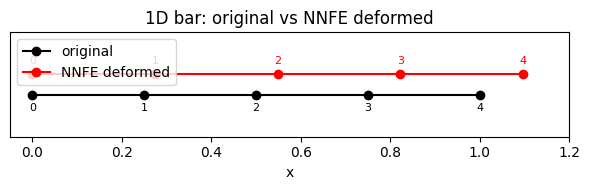

In [ ]:
import matplotlib.pyplot as plt

scale = 1.0  # increase to exaggerate deformation
x_def = x + scale * u_pred

fig, ax = plt.subplots(figsize=(6, 2))

# original
ax.plot(x, 0*x, 'ko-', label="original")

# deformed (shifted up for clarity)
ax.plot(x_def, 0.05 + 0*x_def, 'ro-', label="NNFE deformed")

for i, (xo, xd) in enumerate(zip(x, x_def)):
    ax.text(xo, -0.02, f'{i}', ha='center', va='top', fontsize=8, color='k')
    ax.text(xd, 0.07, f'{i}', ha='center', va='bottom', fontsize=8, color='r')

ax.set_ylim(-0.1, 0.15)
ax.set_xlim(-0.05, L + 0.2)
ax.set_yticks([])
ax.set_xlabel("x")
ax.set_title("1D bar: original vs NNFE deformed")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


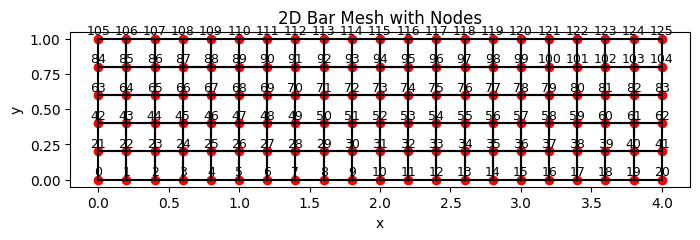

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Bar dimensions
L = 4.0
H = 1.0
nx = 20     # finer mesh for better bending capture
ny = 5

# Generate node grid
x = np.linspace(0, L, nx+1)
y = np.linspace(0, H, ny+1)

X, Y = np.meshgrid(x, y)

nodes = np.column_stack([X.flatten(), Y.flatten()])

# Plot mesh
plt.figure(figsize=(8,3))

# Draw elements
for j in range(ny):
    for i in range(nx):
        n1 = j*(nx+1) + i
        n2 = n1 + 1
        n3 = n2 + (nx+1)
        n4 = n1 + (nx+1)

        element_nodes = [n1, n2, n3, n4, n1]

        plt.plot(nodes[element_nodes,0], nodes[element_nodes,1], 'k-')

# Plot nodes
plt.scatter(nodes[:,0], nodes[:,1], color='red')

# Label nodes
for i,(x,y) in enumerate(nodes):
    plt.text(x, y+0.03, str(i), ha='center', fontsize=9)

plt.title("2D Bar Mesh with Nodes")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal')

plt.show()

FEM tip deflection (node near free end mid-height): 0.026217599741705833
Analytical cantilever deflection: 0.0256


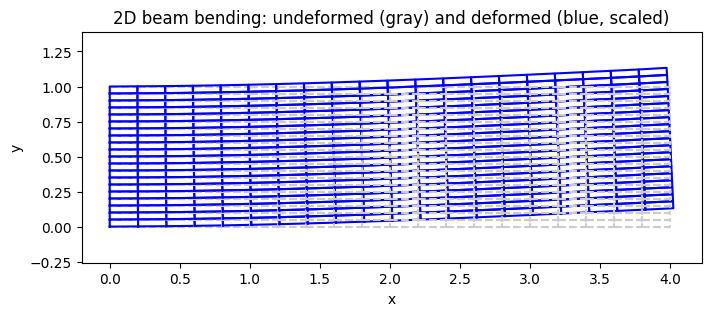

In [ ]:
# code_2_fea_bending.py

import numpy as np
import matplotlib.pyplot as plt

# Geometry and mesh
L = 4.0
H = 1.0
nx = 20     # finer mesh for better bending capture
ny = 20

x = np.linspace(0, L, nx + 1)
y = np.linspace(0, H, ny + 1)
X, Y = np.meshgrid(x, y)
nodes = np.column_stack([X.flatten(), Y.flatten()])
n_nodes = nodes.shape[0]

elements = []
for j in range(ny):
    for i in range(nx):
        n1 = j * (nx + 1) + i
        n2 = n1 + 1
        n3 = n2 + (nx + 1)
        n4 = n1 + (nx + 1)
        elements.append([n1, n2, n3, n4])
elements = np.array(elements, dtype=int)
n_elem = elements.shape[0]

# Material (plane stress)
E = 1e5
nu = 0.3
t = 1.0  # thickness
D = (E / (1 - nu**2)) * np.array(
    [[1.0, nu, 0.0],
     [nu, 1.0, 0.0],
     [0.0, 0.0, (1 - nu) / 2]]
)

# 2x2 Gauss quadrature
gp = np.array([-1/np.sqrt(3), 1/np.sqrt(3)])
w = np.array([1.0, 1.0])

def shape_funcs(xi, eta):
    N1 = 0.25 * (1 - xi) * (1 - eta)
    N2 = 0.25 * (1 + xi) * (1 - eta)
    N3 = 0.25 * (1 + xi) * (1 + eta)
    N4 = 0.25 * (1 - xi) * (1 + eta)
    return np.array([N1, N2, N3, N4])

def dN_dxi_eta(xi, eta):
    dN_dxi = 0.25 * np.array([
        [-(1 - eta), -(1 - xi)],   # N1: dN/dxi, dN/deta
        [ (1 - eta), -(1 + xi)],
        [ (1 + eta),  (1 + xi)],
        [-(1 + eta),  (1 - xi)],
    ])
    # rows: N1..N4, columns: [dN/dxi, dN/deta]
    return dN_dxi

# Global stiffness
ndof = 2 * n_nodes
K = np.zeros((ndof, ndof))
f = np.zeros(ndof)

for e in range(n_elem):
    conn = elements[e]
    xe = nodes[conn, :]  # (4,2)
    Ke = np.zeros((8, 8))
    for i, xi in enumerate(gp):
        for j, eta in enumerate(gp):
            dN = dN_dxi_eta(xi, eta)  # (4,2)
            J = dN.T @ xe            # (2,2)
            detJ = np.linalg.det(J)
            invJ = np.linalg.inv(J)
            dN_dx = dN @ invJ        # (4,2)
            B = np.zeros((3, 8))
            for a in range(4):
                B[0, 2*a]   = dN_dx[a, 0]
                B[1, 2*a+1] = dN_dx[a, 1]
                B[2, 2*a]   = dN_dx[a, 1]
                B[2, 2*a+1] = dN_dx[a, 0]
            weight = w[i] * w[j]
            Ke += B.T @ D @ B * detJ * weight * t

    # assemble Ke into K
    dofs = np.zeros(8, dtype=int)
    for a in range(4):
        dofs[2*a]   = 2*conn[a]
        dofs[2*a+1] = 2*conn[a] + 1
    for i in range(8):
        for j in range(8):
            K[dofs[i], dofs[j]] += Ke[i, j]

# Loads: approximate end load at top right nodes
P = 10.0  # downward
top_right_nodes = np.where(np.isclose(nodes[:, 0], L) & np.isclose(nodes[:, 1], H))[0]
if len(top_right_nodes) == 0:
    # distribute over all right-edge top half nodes
    right_nodes = np.where(np.isclose(nodes[:,0], L))[0]
    top_right_nodes = right_nodes

for nid in top_right_nodes:
    f[2*nid + 1] += P / len(top_right_nodes)

# Boundary conditions: clamp left edge (x=0)
left_nodes = np.where(np.isclose(nodes[:, 0], 0.0))[0]
fixed_dofs = []
for nid in left_nodes:
    fixed_dofs.extend([2*nid, 2*nid+1])
fixed_dofs = np.array(fixed_dofs, dtype=int)

free_dofs = np.setdiff1d(np.arange(ndof), fixed_dofs)

# Solve
K_ff = K[np.ix_(free_dofs, free_dofs)]
f_f  = f[free_dofs]
u = np.zeros(ndof)
u_f = np.linalg.solve(K_ff, f_f)
u[free_dofs] = u_f
u_nodes = u.reshape(-1, 2)

# Analytical tip deflection (Euler-Bernoulli cantilever)
b = 1.0
h = H
I = b * h**3 / 12
delta_tip_analytical = P * L**3 / (3 * E * I)
tip_node = np.argmin((nodes[:,0]-L)**2 + (nodes[:,1]-H/2)**2)
delta_tip_fem = u_nodes[tip_node, 1]

print("FEM tip deflection (node near free end mid-height):", delta_tip_fem)
print("Analytical cantilever deflection:", delta_tip_analytical)

# Plot deformed shape
scale = 5.0  # exaggeration
nodes_def = nodes + scale * u_nodes

plt.figure(figsize=(8,3))
for conn in elements:
    xy0 = nodes[conn]
    xy1 = nodes_def[conn]
    xy0c = np.vstack([xy0, xy0[0]])
    xy1c = np.vstack([xy1, xy1[0]])
    plt.plot(xy0c[:,0], xy0c[:,1], color='0.8', linestyle='--') # Corrected line
    plt.plot(xy1c[:,0], xy1c[:,1], 'b-')

plt.axis('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D beam bending: undeformed (gray) and deformed (blue, scaled)")
plt.show()

In [ ]:
!pip install --quiet jax jaxlib optax flax
!git clone https://github.com/deepmodeling/jax-fem.git
%cd jax-fem
!pip install -e .

!apt-get install -y gmsh
!pip install meshio
# 1) System-level gmsh
!apt-get update -qq
!apt-get install -y gmsh

# 2) Python packages used by jax_fem.generate_mesh
!pip install --quiet meshio gmsh

!apt-get update
!apt-get install -y libopenmpi-dev
!pip install --quiet petsc4py

!pip install jax jaxlib
!pip install git+https://github.com/deepmodeling/jax-fem.git
!pip install meshio pyvista

!pip install petsc petsc4py
!pip install pyfiglet meshio pyvista gmsh fenics-basix pypardiso

!apt-get update
!apt-get install -y libglu1-mesa



fatal: destination path 'jax-fem' already exists and is not an empty directory.
/content/jax-fem
Obtaining file:///content/jax-fem
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jax-fem (pyproject.toml) ... done
  Created wheel for jax-fem: filename=jax_fem-0.0.11-py3-none-any.whl size=27642 sha256=e50a3cfea4831821d078c0998ba9e6829c9c1ad9f7428bf40b010939fdb31588
  Stored in directory: /tmp/pip-ephem-wheel-cache-v9_jpxvw/wheels/46/af/b4/5acfdc1338be3548c1ec16770c05d2024a6f8eb03bcc2c501b
Successfully built jax-fem
  Attempting uninstall: jax-fem
    Found existing installation: jax-fem 0.0.11
    Uninstalling jax-fem-0.0.11:
      Successfully uninstalled jax-fem-0.0.11
Reading package lists... Done
Building dependency tree... Done
Reading state information... Don

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                   ^^^^^^^^
  File "/usr/local/lib/py

In [1]:
from jax_fem.problem import Problem
print("JAX-FEM installed successfully")
import jax
import jax_fem

print("JAX version:", jax.__version__)
print("JAX-FEM loaded correctly")

!sed -i 's/QuadratureType.default/QuadratureType.Default/g' /content/jax-fem/jax_fem/basis.py
!sed -i 's/return basix.QuadratureType.Default/return None/g' /content/jax-fem/jax_fem/basis.py

#Restart Session

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              

JAX-FEM installed successfully
JAX version: 0.7.2
JAX-FEM loaded correctly


In [1]:
import jax
import jax_fem

print("JAX version:", jax.__version__)
print("JAX-FEM loaded successfully")


       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              

JAX version: 0.7.2
JAX-FEM loaded successfully


In [2]:
import jax_fem
print(jax_fem.__file__)

/usr/local/lib/python3.12/dist-packages/jax_fem/__init__.py


In [10]:
from jax_fem.problem import Problem
print("JAX-FEM installed successfully")
import jax
import jax_fem

print("JAX version:", jax.__version__)
print("JAX-FEM loaded correctly")

!sed -i 's/QuadratureType.default/QuadratureType.Default/g' /content/jax-fem/jax_fem/basis.py
!sed -i 's/return basix.QuadratureType.Default/return None/g' /content/jax-fem/jax_fem/basis.py

#Restart Session

JAX-FEM installed successfully
JAX version: 0.7.2
JAX-FEM loaded correctly


In [3]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
import jax.numpy as jnp

from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.generate_mesh import rectangle_mesh
from jax_fem.utils import save_sol


[05-17 17:57:26][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.


In [4]:
import jax
import jax.numpy as np
import os

from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import get_meshio_cell_type, Mesh, rectangle_mesh

class Poisson(Problem):
    def get_tensor_map(self):
        return lambda x: x

    def get_mass_map(self):
        def mass_map(u, x):
            val = -np.array([10*np.exp(-(np.power(x[0] - 0.5, 2) + np.power(x[1] - 0.5, 2)) / 0.02)])
            return val
        return mass_map

ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)
Lx, Ly = 1., 1.
meshio_mesh = rectangle_mesh(Nx=32, Ny=32, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])

def left(point):
    return np.isclose(point[0], 0., atol=1e-5)

def right(point):
    return np.isclose(point[0], Lx, atol=1e-5)

def bottom(point):
    return np.isclose(point[1], 0., atol=1e-5)

def top(point):
    return np.isclose(point[1], Ly, atol=1e-5)

def dirichlet_val(point):
    return 0.

location_fns = [left, right, bottom, top]
value_fns = [dirichlet_val]*4
vecs = [0]*4
dirichlet_bc_info = [location_fns, vecs, value_fns]

problem = Poisson(mesh=mesh, vec=1, dim=2, ele_type=ele_type, dirichlet_bc_info=dirichlet_bc_info)
sol = solver(problem)


data_dir = './data'
os.makedirs(data_dir, exist_ok=True)
os.makedirs('./data/vtk', exist_ok=True)
vtk_path = './data/vtk/u.vtu'
save_sol(problem.fes[0], sol[0], vtk_path)


[05-17 17:57:30][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[05-17 17:57:30][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[05-17 17:57:30][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[05-17 17:57:31][DEBUG] jax_fem: Done pre-computations, took 1.1262142658233643 [s]
[05-17 17:57:31][INFO] jax_fem: Solving a problem with 1024 cells, 1089x1 = 1089 dofs.
[05-17 17:57:31][INFO] jax_fem: Element type is QUAD4, using 4 quad points per element.
[05-17 17:57:31][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[05-17 17:57:31][DEBUG] jax_fem: Start timing
[05-17 17:57:31][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[05-17 17:57:32][DEBUG] jax_fem: Function split_and_compute_cell took 0.4405 seconds
[05-17 17:57:32][DEBUG] jax_fem: Creating sparse matrix with scipy...
[05-17 17:57:33][DEBUG] jax_fem: Before, l_2 res = 0.054943858112556296, relative l_

Warning: VTU requires 3D points, but 2D points given. Appending 0 third component.

In [15]:
# Import some useful modules.
import jax.numpy as np
import numpy as onp
import os
import pypardiso
import scipy

# Import JAX-FEM specific modules.
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh_gmsh, get_meshio_cell_type, Mesh
from jax_fem import logger

import logging
logger.setLevel(logging.DEBUG)

# Material properties.
E = 70e3
nu = 0.3
mu = E/(2.*(1.+nu))
lmbda = E*nu/((1+nu)*(1-2*nu))

# Weak forms.
class LinearElasticity(Problem):
    # The function 'get_tensor_map' overrides base class method. Generally, JAX-FEM
    # solves -div(f(u_grad)) = b. Here, we have f(u_grad) = sigma.
    def get_tensor_map(self):
        def stress(u_grad):
            epsilon = 0.5 * (u_grad + u_grad.T)
            sigma = lmbda * np.trace(epsilon) * np.eye(self.dim) + 2*mu*epsilon
            return sigma
        return stress

    def get_surface_maps(self):
        def surface_map(u, x):
            return np.array([0., 0., 100.])
        return [surface_map]


# Specify mesh-related information (second-order tetrahedron element).
ele_type = 'TET10'
cell_type = get_meshio_cell_type(ele_type)
data_dir = './data'
os.makedirs(data_dir, exist_ok=True)
Lx, Ly, Lz = 10., 2., 2.
Nx, Ny, Nz = 25, 5, 5
meshio_mesh = box_mesh_gmsh(Nx=Nx,
                       Ny=Ny,
                       Nz=Nz,
                       domain_x=Lx,
                       domain_y=Ly,
                       domain_z=Lz,
                       data_dir=data_dir,
                       ele_type=ele_type)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])

# Define boundary locations.
def left(point):
    return np.isclose(point[0], 0., atol=1e-5)

def right(point):
    return np.isclose(point[0], Lx, atol=1e-5)


# Define value function.
def zero_dirichlet_val(point):
    return 0.

# Define Dirichlet boundary values.
# This means on the 'left' side, we apply the function 'zero_dirichlet_val'
# to all components of the displacement variable u.
dirichlet_bc_info = [[left] * 3, [0, 1, 2], [zero_dirichlet_val] * 3]

# Define Neumann boundary locations.
# This means on the 'right' side, we will perform the surface integral to get
# the tractions with the function 'get_surface_maps' defined in the class 'LinearElasticity'.
location_fns = [right]

# Create an instance of the problem.
problem = LinearElasticity(mesh,
                           vec=3,
                           dim=3,
                           ele_type=ele_type,
                           dirichlet_bc_info=dirichlet_bc_info,
                           location_fns=location_fns)

def pardiso_solver(A, b, x0, solver_options):
    """
    Solves Ax=b with x0 being the initial guess.

    A: PETSc sparse matrix
    b: JaxArray
    x0: JaxArray (forward problem) or None (adjoint problem)
    solver_options: anything the user defines, at least satisfying solver_options['custom_solver'] = pardiso_solver
    """
    logger.debug(f"Pardiso Solver - Solving linear system")

    # If you need to convert PETSc to scipy
    indptr, indices, data = A.getValuesCSR()
    A_sp_scipy = scipy.sparse.csr_array((data, indices, indptr), shape=A.getSize())
    x = pypardiso.spsolve(A_sp_scipy, onp.array(b))
    return x


# Solve the defined problem.
sol_list = solver(problem, solver_options={'custom_solver': pardiso_solver})

# Postprocess for stress evaluations
# (num_cells, num_quads, vec, dim)
u_grad = problem.fes[0].sol_to_grad(sol_list[0])
epsilon = 0.5 * (u_grad + u_grad.transpose(0,1,3,2))
# (num_cells, bnum_quads, 1, 1) * (num_cells, num_quads, vec, dim)
# -> (num_cells, num_quads, vec, dim)
sigma = lmbda * np.trace(epsilon, axis1=2, axis2=3)[:,:,None,None] * np.eye(problem.dim) + 2*mu*epsilon
# (num_cells, num_quads)
cells_JxW = problem.JxW[:,0,:]
# (num_cells, num_quads, vec, dim) * (num_cells, num_quads, 1, 1) ->
# (num_cells, vec, dim) / (num_cells, 1, 1)
#  --> (num_cells, vec, dim)
sigma_average = np.sum(sigma * cells_JxW[:,:,None,None], axis=1) / np.sum(cells_JxW, axis=1)[:,None,None]

# Von Mises stress
# (num_cells, dim, dim)
s_dev = (sigma_average - 1/problem.dim * np.trace(sigma_average, axis1=1, axis2=2)[:,None,None]
                                       * np.eye(problem.dim)[None,:,:])
# (num_cells,)
vm_stress = np.sqrt(3./2.*np.sum(s_dev*s_dev, axis=(1,2)))

# Store the solution to local file.
vtk_path = os.path.join(data_dir, 'vtk/u.vtu')
save_sol(problem.fes[0], sol_list[0], vtk_path, cell_infos=[('vm_stress', vm_stress)])

[05-17 18:00:09][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[05-17 18:00:09][DEBUG] jax_fem: ele_type = TET10, quad_points.shape = (num_quads, dim) = (4, 3)
[05-17 18:00:09][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 3, 3)
[05-17 18:00:09][DEBUG] jax_fem: Done pre-computations, took 0.01182866096496582 [s]
[05-17 18:00:09][INFO] jax_fem: Solving a problem with 3750 cells, 6171x3 = 18513 dofs.
[05-17 18:00:09][INFO] jax_fem: Element type is TET10, using 4 quad points per element.
[05-17 18:00:09][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[05-17 18:00:09][DEBUG] jax_fem: Start timing
[05-17 18:00:09][DEBUG] jax_fem: Computing cell Jacobian and cell residual...


[05-17 18:00:09][DEBUG] jax_fem: Function split_and_compute_cell took 0.3005 seconds
[05-17 18:00:09][DEBUG] jax_fem: Creating sparse matrix with scipy...
[05-17 18:00:09][DEBUG] jax_fem: Before, l_2 res = 44.62186808181724, relative l_2 res = 1.0
[05-17 18:00:09][DEBUG] jax_fem: Solving linear system...
[05-17 18:00:09][DEBUG] jax_fem: Pardiso Solver - Solving linear system
[05-17 18:00:09][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[05-17 18:00:09][DEBUG] jax_fem: Function split_and_compute_cell took 0.0149 seconds
[05-17 18:00:09][DEBUG] jax_fem: Creating sparse matrix with scipy...
[05-17 18:00:10][DEBUG] jax_fem: l_2 res = 7.021997662711997e-10, relative l_2 res = 1.573667343966121e-11
[05-17 18:00:10][INFO] jax_fem: Solve took 0.4947679042816162 [s]
[05-17 18:00:10][INFO] jax_fem: max of dofs = 0.21325867298100246
[05-17 18:00:10][INFO] jax_fem: min of dofs = -1.451117913991673
